In [14]:
import urllib.request

url = "https://maxi.riken.jp/star_data/J1612-524/J1612-524_g_lc_1day_all.dat"
fname = "J1612-524_g_lc_1day_all.dat"

urllib.request.urlretrieve(url, fname)

('J1612-524_g_lc_1day_all.dat', <http.client.HTTPMessage at 0x118b2cfc0>)

In [15]:
import pandas as pd

cols = [
    "mjd",
    "flux_2_20", "err_2_20",
    "flux_2_4", "err_2_4",
    "flux_4_10", "err_4_10",
    "flux_10_20", "err_10_20",
]

df = pd.read_csv(fname, sep=r"\s+", names=cols)
print(df.shape)
df.head()

(5146, 9)


,mjd,flux_2_20,err_2_20,flux_2_4,err_2_4,flux_4_10,err_4_10,flux_10_20,err_10_20
0,55053.5,0.108890,0.082890,0.074699,0.054621,0.029035,0.036475,0.011473,0.045402
1,55054.5,0.231242,0.027672,0.104946,0.016991,0.075329,0.012614,0.044073,0.015052
2,55055.5,0.168920,0.019135,0.083585,0.011879,0.057979,0.008962,0.024726,0.009989
3,55056.5,0.127611,0.013072,0.072002,0.008256,0.041419,0.006041,0.015974,0.007119
4,55057.5,0.135478,0.009858,0.077589,0.005778,0.045598,0.004439,0.012955,0.005717


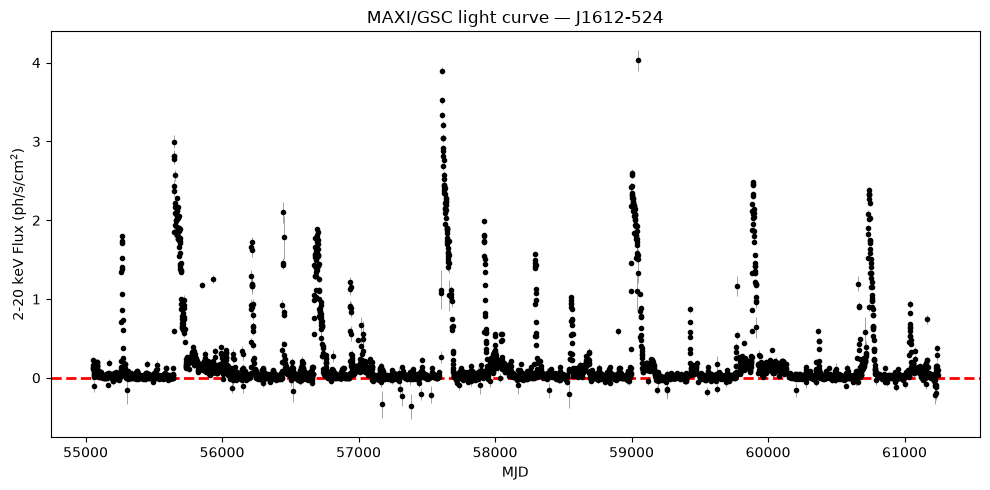

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    df["mjd"], df["flux_2_20"], yerr=df["err_2_20"],
    fmt="o", ms=3, elinewidth=0.5, capsize=0, color="k", ecolor="gray", label="MAXI data"
)
ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux (ph/s/cm$^2$)")
ax.set_title("MAXI/GSC light curve — J1612-524")
ax.axhline(0, color="red", lw=2, ls="--", label="Zero Flux")
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

sig = df["flux_2_20"] / df["err_2_20"].replace(0, np.nan)
mask = (df["flux_2_20"] > 0) & (sig > 2)   # keep >2 sigma detections only

clean = df[mask].sort_values("mjd").reset_index(drop=True)
print(f"{len(clean)} / {len(df)} points kept")

2896 / 5146 points kept


# as discussed in our meetings, this is not yeilding good detections... probably because data sampling is not right, lets try and fix that

In [19]:
from scipy.ndimage import uniform_filter1d

mjd_grid = np.arange(clean["mjd"].min(), clean["mjd"].max() + 1, 1.0)
flux_grid = np.interp(mjd_grid, clean["mjd"].values, clean["flux_2_20"].values)
flux_smooth = uniform_filter1d(flux_grid, size=5)

lets check if this step made any difference

In [20]:
delta_t_before, delta_t_after = np.diff(clean["mjd"]), np.diff(mjd_grid)
print(f"Median delta_t (before): {np.mean(delta_t_before):.3f} days")
print(f"Median delta_t (after): {np.mean(delta_t_after):.3f} days")

Median delta_t (before): 2.137 days
Median delta_t (after): 1.000 days


It worked!! notice that I am taking the mean here...not the median.. np.diff will give me all the delta t values... median would afcourse be 1, as in most of the cases, the data is recorded every one day. However, mean will give me the average delta t, which is more useful in this case, as it will give me an idea of how much the data is sampled on average. If the mean is significantly greater than 1, it means that there are gaps in the data, which can affect the peak finding algorithm (as we are using the width/distance parameter in find_peaks). Once we have interpolated the data to a uniform grid, we can use the mean delta t to set the distance parameter in find_peaks, which will help us avoid detecting multiple peaks for a single outburst. See how the mean delta t after the interpolations sits at 1.00 which is great for us!! 

In [22]:
# establish the baseline level of the flux, i.e., the median.. this will give us a good estimate of the persistent flux level of the source, ignoring any outbursts or flares.
baseline = np.median(flux_smooth)

# lets calculate the MAD (median absolute deviation) which is a robust measure of variability. It is less sensitive to outliers than the standard deviation. We will use this to define a threshold for detecting "active" periods in the light curve.
mad = np.median(np.abs(flux_smooth - baseline))

# this is the trick. I will explain why we are doing this in the cell below.
sigma_robust = 1.4826 * mad   

# 5 sigma threshold.
n_sigma = 5
threshold = baseline + n_sigma * sigma_robust

print(f"baseline={baseline:.3f}, robust sigma={sigma_robust:.3f}, threshold={threshold:.3f}")

baseline=0.070, robust sigma=0.058, threshold=0.358


We ultimately need a 5 sigma cut, but by through the MAD, and not a simple standard deviation. 

1 MAD is not exactly eqvivalent to 1 standard deviation (i.e 1 MAD $\neq 1 \sigma$), but it can be converted to a "sigma"-like scale by multiplying by 1.4826. The number comes for the fact that, 1 MAD $\sim 0.6745 \sigma$

so $1 \sigma \sim 1/0.6745 = 1.4826$ MAD.

# lets find some peaks!
Philosophically, there are 2 approcahes, algorithmioc and a scientific approach. The algorithmic approach is to use a peak finding algorithm, such as scipy.signal.find_peaks, which is a general-purpose peak-finding algorithm that can be applied to any 1D array. The scientific method would be a model based approach, where you establish an outburst model and fit it to the data and retrive the peaks. The scientific approach, while more robust, is an overkill for what we are trying to do. So lets stick to an algorithmic approach for now.

# NOTE:
There are many ways to find peaks in a light curve, and the best approach depends on the specific characteristics of the data and the goals of the analysis. Here, we will use a simple, general-purpose peak-finding algorithm from the scipy library, which is fast and easy to use. However, there may be other ways of doing the same thing.


# try 1
use ```scipy.signal.find_peaks``` on the smoothed light curve with three constraints: an absolute height floor, a prominence (how much a peak must rise above its local surroundings), and a distance (minimum days between two accepted peaks). This is the standard, general-purpose peak-finding approach. fast and simple, but the distance parameter has to be tuned to roughly match the real outburst spacing, otherwise a single broad, bumpy outburst can get split into multiple "peaks," or peaks from different outbursts can get merged if they're too close together. Adding on top of this is the non uniformity of the data we saw earlier, can make it difficult. The trick is to understand your data more thoroughly before applying the algorithm, and to tune the parameters accordingly.

In [23]:
from scipy.signal import find_peaks

peaks, props = find_peaks(
    flux_smooth,
    height=threshold,
    prominence=n_sigma * sigma_robust,
    distance=60   # you can play around this value as this may be unique for each source!
)

peak_mjd_simple = mjd_grid[peaks]
peak_flux_simple = flux_smooth[peaks]

print(f"Method 1 found {len(peak_mjd_simple)} peaks:")
for m, f in zip(peak_mjd_simple, peak_flux_simple):
    print(f"  MJD {m:.1f}   flux={f:.2f}")

Method 1 found 23 peaks:
  MJD 55265.5   flux=1.63
  MJD 55648.5   flux=2.77
  MJD 55931.5   flux=0.37
  MJD 56216.5   flux=1.49
  MJD 56446.5   flux=1.71
  MJD 56698.5   flux=1.76
  MJD 56939.5   flux=1.06
  MJD 57032.5   flux=0.46
  MJD 57613.5   flux=3.48
  MJD 57920.5   flux=1.81
  MJD 58046.5   flux=0.50
  MJD 58293.5   flux=1.47
  MJD 58557.5   flux=0.96
  MJD 58899.5   flux=0.44
  MJD 59001.5   flux=2.47
  MJD 59423.5   flux=0.80
  MJD 59773.5   flux=1.06
  MJD 59888.5   flux=2.40
  MJD 60367.5   flux=0.54
  MJD 60660.5   flux=1.08
  MJD 60739.5   flux=2.33
  MJD 61039.5   flux=0.74
  MJD 61163.5   flux=0.48


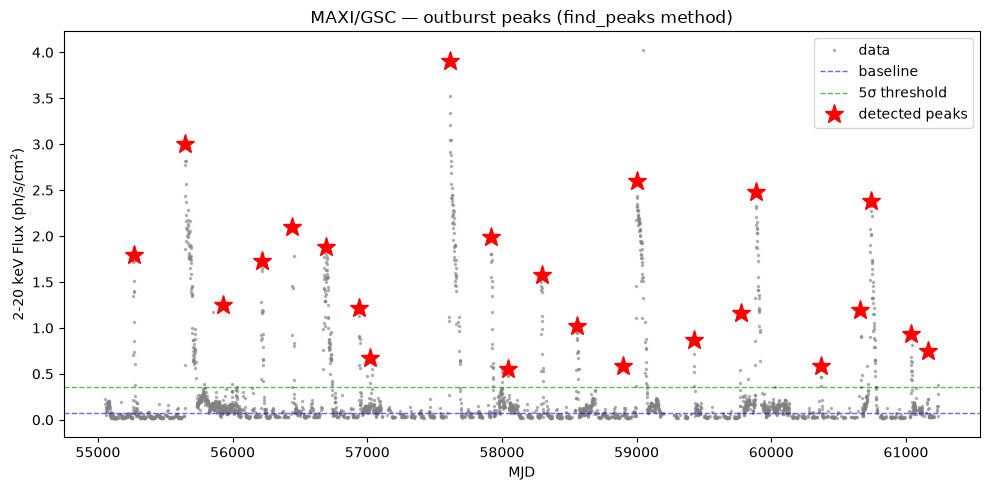

In [27]:
import matplotlib.pyplot as plt

refined_mjd_simple, refined_flux_simple = refine_peaks(peak_mjd_simple)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(clean["mjd"], clean["flux_2_20"], ".", color="gray", ms=3, alpha=0.5, label="data")
ax.axhline(baseline, color="blue", lw=1, ls="--", alpha=0.6, label="baseline")
ax.axhline(threshold, color="green", lw=1, ls="--", alpha=0.6, label=f"{n_sigma}σ threshold")
ax.plot(refined_mjd_simple, refined_flux_simple, "r*", ms=14, label="detected peaks")

ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux (ph/s/cm$^2$)")
ax.set_title("MAXI/GSC — outburst peaks (find_peaks method)")
ax.legend()
plt.tight_layout()
plt.show()

Great, we are finding some real peaks.. but we are alos picking some noises!

There are few ways of improving this.. 

1. we can play arounf the find_peaks parameters, until we get what we want.. but that would invlice doing it for each source... Honestly fater to do if there are only few sources. 
2. We can use a slighly better approach, that is used and discussed below 

Instead of hunting for local maxima directly, this labels every contiguous stretch of days where the smoothed flux stays above the noise threshold, discards stretches shorter than min_run_days (kills brief noise excursions), and then takes one peak per surviving stretch. This also maps more directly onto the physical definition of "an outburst" a sustained period of elevated flux. So it's structurally immune to splitting one bumpy outburst into several peaks, since by construction it only ever returns one peak per contiguous active region. The main knob here is ```min_run_days``` rather than distance.

In short: this method finds peaks by grouping (contiguous active regions),

In [29]:
from scipy.ndimage import label

min_run_days = 10   # minimum duration for a stretch to count as a real outburst (rejects 1-day spikes)

active = flux_smooth > threshold
labels, n_groups = label(active)

peak_mjd_runs, peak_flux_runs = [], []
for g in range(1, n_groups + 1):
    idx = np.where(labels == g)[0]
    if len(idx) < min_run_days:
        continue
    i_max = idx[np.argmax(flux_smooth[idx])]
    peak_mjd_runs.append(mjd_grid[i_max])
    peak_flux_runs.append(flux_smooth[i_max])

print(f"Method 2 found {len(peak_mjd_runs)} peaks:")
for m, f in zip(peak_mjd_runs, peak_flux_runs):
    print(f"  MJD {m:.1f}   flux={f:.2f}")

Method 2 found 18 peaks:
  MJD 55265.5   flux=1.63
  MJD 55648.5   flux=2.77
  MJD 56216.5   flux=1.49
  MJD 56446.5   flux=1.71
  MJD 56698.5   flux=1.76
  MJD 56939.5   flux=1.06
  MJD 57613.5   flux=3.48
  MJD 57920.5   flux=1.81
  MJD 58293.5   flux=1.47
  MJD 58557.5   flux=0.96
  MJD 59001.5   flux=2.47
  MJD 59423.5   flux=0.80
  MJD 59773.5   flux=1.06
  MJD 59888.5   flux=2.40
  MJD 60367.5   flux=0.54
  MJD 60660.5   flux=1.08
  MJD 60739.5   flux=2.33
  MJD 61039.5   flux=0.74


we got fewer peaks than before!! that is a good news! lets plot it..

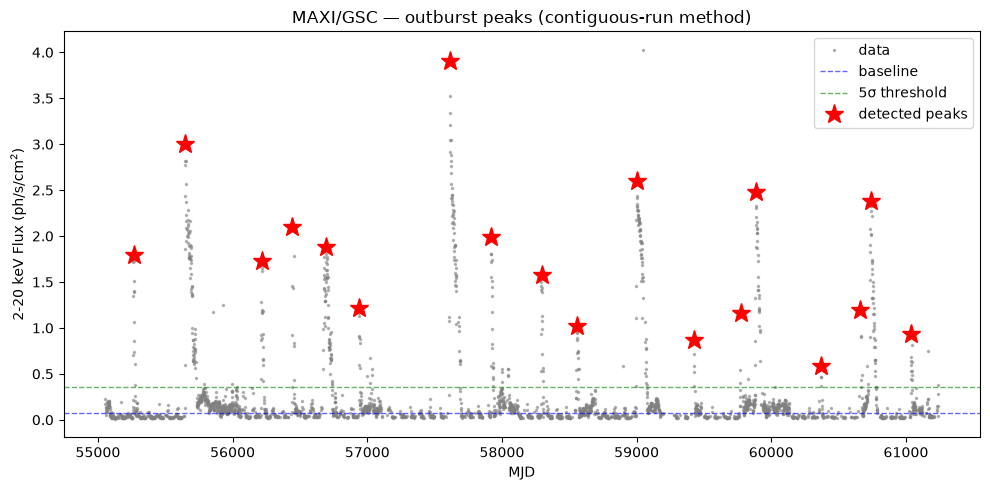

In [31]:
refined_mjd_runs, refined_flux_runs = refine_peaks(peak_mjd_runs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(clean["mjd"], clean["flux_2_20"], ".", color="gray", ms=3, alpha=0.5, label="data")
ax.axhline(baseline, color="blue", lw=1, ls="--", alpha=0.6, label="baseline")
ax.axhline(threshold, color="green", lw=1, ls="--", alpha=0.6, label=f"{n_sigma}σ threshold")
ax.plot(refined_mjd_runs, refined_flux_runs, "r*", ms=14, label="detected peaks")

ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux (ph/s/cm$^2$)")
ax.set_title("MAXI/GSC — outburst peaks (contiguous-run method)")
ax.legend()
plt.tight_layout()
plt.show()

neat! it looks like it got rid of almost all of the noises! with a couple of exceptions! ANything beyond these filtering can be done manually in my opinion.. but an even more advanced way of filtering the peaks is also possible.. like calculating fluence per each peak, and setting a threshold based on that... i,e this falls into the scientific approach of filtering. 

In [32]:
def refine_peaks(peak_mjds, window_days=15):
    refined_mjd, refined_flux = [], []
    for m in peak_mjds:
        window = clean[(clean["mjd"] > m - window_days) & (clean["mjd"] < m + window_days)]
        if len(window):
            j = window["flux_2_20"].idxmax()
            refined_mjd.append(clean.loc[j, "mjd"])
            refined_flux.append(clean.loc[j, "flux_2_20"])
    return refined_mjd, refined_flux

refined_mjd_simple, refined_flux_simple = refine_peaks(peak_mjd_simple)
refined_mjd_runs, refined_flux_runs = refine_peaks(peak_mjd_runs)

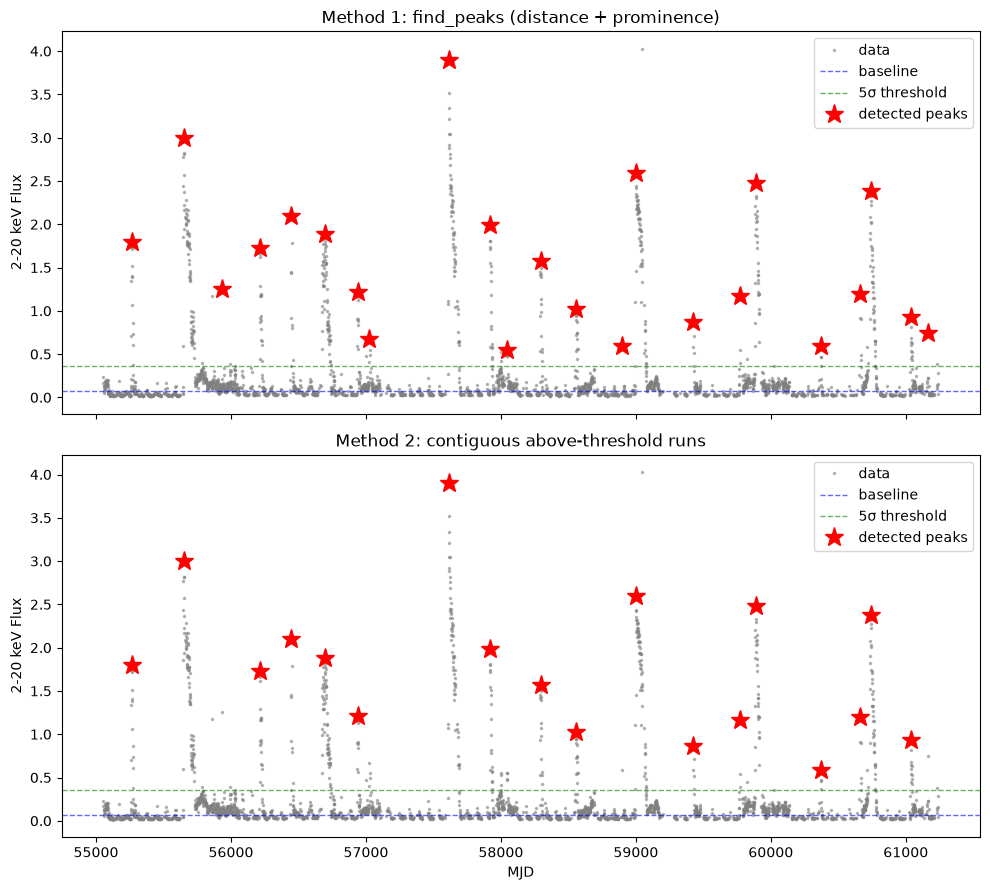

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

for ax, mjds, fluxes, title in [
    (axes[0], refined_mjd_simple, refined_flux_simple, "Method 1: find_peaks (distance + prominence)"),
    (axes[1], refined_mjd_runs, refined_flux_runs, "Method 2: contiguous above-threshold runs"),
]:
    ax.plot(clean["mjd"], clean["flux_2_20"], ".", color="gray", ms=3, alpha=0.5, label="data")
    ax.axhline(baseline, color="blue", lw=1, ls="--", alpha=0.6, label="baseline")
    ax.axhline(threshold, color="green", lw=1, ls="--", alpha=0.6, label=f"{n_sigma}σ threshold")
    ax.plot(mjds, fluxes, "r*", ms=14, label="detected peaks")
    ax.set_ylabel("2-20 keV Flux")
    ax.set_title(title)
    ax.legend()

axes[-1].set_xlabel("MJD")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# use median + MAD (median absolute deviation) — robust to outliers/outbursts
baseline = np.median(flux_smooth)
mad = np.median(np.abs(flux_smooth - baseline))
sigma_robust = 1.4826 * mad   # converts MAD to a "sigma"-like scale

print(f"baseline={baseline:.3f}, robust sigma={sigma_robust:.3f}")

In [ ]:
from scipy.signal import find_peaks

n_sigma_height = 7     # peak must be 5 robust-sigma above baseline
n_sigma_prom   = 5       # and stand out from local surroundings by same amount

peaks, props = find_peaks(
    flux_smooth,
    height=baseline + n_sigma_height * sigma_robust,
    prominence=n_sigma_prom * sigma_robust,
    distance=100   # this one is still physically motivated (expected outburst spacing), not noise-derived
)

peak_mjd = mjd_grid[peaks]
peak_flux = flux_smooth[peaks]

In [ ]:
import matplotlib.pyplot as plt

# snap each smoothed-peak MJD to the true max raw flux within +/-15 days
refined_mjd, refined_flux = [], []
for m in peak_mjd:
    window = clean[(clean["mjd"] > m - 15) & (clean["mjd"] < m + 15)]
    if len(window):
        idx = window["flux_2_20"].idxmax()
        refined_mjd.append(clean.loc[idx, "mjd"])
        refined_flux.append(clean.loc[idx, "flux_2_20"])

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(clean["mjd"], clean["flux_2_20"], ".", color="gray", ms=3, alpha=0.5, label="data")
ax.axhline(baseline, color="blue", lw=1, ls="--", alpha=0.6, label="baseline")
ax.axhline(baseline + n_sigma_height * sigma_robust, color="green", lw=1, ls="--", alpha=0.6, label=f"{n_sigma_height}σ threshold")
ax.plot(refined_mjd, refined_flux, "r*", ms=14, label="detected peaks")

ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux (ph/s/cm$^2$)")
ax.set_title("MAXI/GSC — detected outburst peaks (data-driven thresholds)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Found {len(refined_mjd)} outburst peaks:")
for m, f in zip(refined_mjd, refined_flux):
    print(f"  MJD {m:.1f}   flux={f:.2f}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d, label

# data cleaninf.... get rid of negative fluxes and low-significance points and sort it by mjd.
sig = df["flux_2_20"] / df["err_2_20"].replace(0, np.nan)
mask = (df["flux_2_20"] > 0) & (sig > 2)
clean = df[mask].sort_values("mjd").reset_index(drop=True)

# the data is probably not exactly samplted at 1 day, even though the data says it is.. we can check that 
mjd_grid = np.arange(clean["mjd"].min(), clean["mjd"].max() + 1, 1.0)
flux_grid = np.interp(mjd_grid, clean["mjd"].values, clean["flux_2_20"].values)
flux_smooth = uniform_filter1d(flux_grid, size=5)

delta_t_before, delta_t_after = np.diff(clean["mjd"]), np.diff(mjd_grid)
print(f"Median delta_t (before): {np.mean(delta_t_before):.3f} days")
print(f"Median delta_t (after): {np.mean(delta_t_after):.3f} days")

In [ ]:
#notice that I am taking the mean here...not the median.. np.diff will give me all the delta t values... median would afcourse be 1, as in most of the cases, the data is recorded every one day. However, mean will give me the average delta t, which is more useful in this case, as it will give me an idea of how much the data is sampled on average. If the mean is significantly greater than 1, it means that there are gaps in the data, which can affect the peak finding algorithm (as we are using the width/distance parameter in find_peaks). Once we have interpolated the data to a uniform grid, we can use the mean delta t to set the distance parameter in find_peaks, which will help us avoid detecting multiple peaks for a single outburst. See how the mean delta t after the interpolations sits at 1.00 which is great for us!! 

In [ ]:
## AI (claude) suggested the below approach which is a neat trick.. I will annotate the code to explain the things.

In [ ]:
#first lets establish a baseline level of the counts. i.e the median
baseline = np.median(flux_smooth)

# lets calculate the MAD (median absolute deviation) which is a robust measure of variability. It is less sensitive to outliers than the standard deviation. We will use this to define a threshold for detecting "active" periods in the light curve.
mad = np.median(np.abs(flux_smooth - baseline))

# this is the trick... MAD is not exactly eqvivalent to standard deviation, but it can be converted to a "sigma"-like scale by multiplying by 1.4826. The number comes for the fact that, 1 MAD ~ 0.6745 sigma.. so 1 sigma ~ 1/0.6745 = 1.4826 MAD.
sigma_robust = 1.4826 * mad

# lets define a 5 sigma threshold. 
n_sigma = 5
threshold = baseline + n_sigma * sigma_robust

# -------- 4. label contiguous "active" (above-threshold) stretches --------
active = flux_smooth > threshold
labels, n_groups = label(active)

min_run_days = 10   # require a stretch to last at least this long -> rejects 1-day noise spikes

peak_mjd, peak_flux = [], []
for g in range(1, n_groups + 1):
    idx = np.where(labels == g)[0]
    if len(idx) < min_run_days:
        continue
    # peak = max smoothed flux within this stretch
    i_max = idx[np.argmax(flux_smooth[idx])]
    m = mjd_grid[i_max]

    # snap to the true max in the raw (unsmoothed) data nearby
    window = clean[(clean["mjd"] > m - 15) & (clean["mjd"] < m + 15)]
    if len(window):
        j = window["flux_2_20"].idxmax()
        peak_mjd.append(clean.loc[j, "mjd"])
        peak_flux.append(clean.loc[j, "flux_2_20"])

# -------- 5. plot --------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(clean["mjd"], clean["flux_2_20"], ".", color="gray", ms=3, alpha=0.5, label="data")
ax.axhline(baseline, color="blue", lw=1, ls="--", alpha=0.6, label="baseline")
ax.axhline(threshold, color="green", lw=1, ls="--", alpha=0.6, label=f"{n_sigma}σ threshold")
ax.plot(peak_mjd, peak_flux, "r*", ms=14, label="detected outburst peaks")

ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux (ph/s/cm$^2$)")
ax.set_title("MAXI/GSC — outburst peaks (contiguous-run method)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Found {len(peak_mjd)} outburst peaks:")
for m, f in zip(peak_mjd, peak_flux):
    print(f"  MJD {m:.1f}   flux={f:.2f}")